## Sección 2: Análisis de Fibonacci

En esta sección se evalúa el funcionamiento de la solución multihilo para la generación de la serie de Fibonacci. El objetivo fue implementar un esquema de memoria compartida donde un hilo trabajador genera los datos y el hilo principal los consume (imprime).

### 1. Resultados de Ejecución

A continuación se presenta la salida del programa compilado al solicitar los primeros **15 números** de la secuencia.

**Comando ejecutado:**
`./fibonacci 15`

**Salida obtenida:**

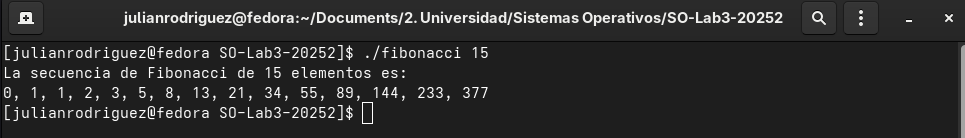

### 2. Análisis del Diseño

Para cumplir con los requerimientos de paralelismo y memoria compartida, se implementaron las siguientes estrategias de diseño:

#### A. Mecanismo de Transferencia de Datos

La API de Pthreads (`thread_create`)  restringe el paso de argumentos a un único puntero de tipo `void*`. Sin embargo, nuestro hilo trabajador requie dos datos: el tamaño de la serie ($N$) y la dirección de memoria del arreglo donde escribir los resultados. Para resolver esto, se definió una estructura personalizada:


```c
typedef struct {
    int size;       // Cantidad de números a generar (N)
    int* result;    // Puntero al arreglo compartido donde se escribirán los datos
} ThreadArgs;
```

El flujo de datos funcionó así:
- El hilo `main` empaquetó los valores en una instancia de `ThreadArgs`.
- Se pasó la referencia de esta estructura (casteada a `void*`) al crear el hilo.
- Dentro de la función `fibonacci_worker`, se realizó el casting inverso (`ThreadArgs*`) para desempaquetar y acceder al puntero del arreglo y al entero $N$.

#### B. Sincronización con `pthread_join`

El uso de pthread_join es crítico en este diseño para evitar condiciones de carrera (Race Conditions).

Dado que el hilo trabajador escribe en el arreglo y el hilo `main` lee del mismo arreglo para imprimir, existe una dependencia de datos estricta.

- Sin sincronización: Si el `main` intentara imprimir inmediatamente después de crear el hilo, leería posiciones de memoria que aún no han sido escritas (basura o ceros), ya que el planificador del SO podría no haber ejecutado aún al hilo trabajador.

- Con sincronización: Al invocar `pthread_join(tid, NULL)`, el hilo main se bloquea y espera obligatoriamente a que el trabajador finalice su ejecución (y por ende, termine de escribir en memoria). Esto garantiza que, al momento de imprimir, los datos en el arreglo compartido sean válidos y completos.